# Design Pattern: Package-Skill with Internal Retry Mechanism

## Background & Motivation
When designing advanced Agentic workflows, it is natural to conceptualize the execution as a **DAG (Directed Acyclic Graph)** where a Planner generates a sequence of skills to be executed. However, when transitioning from a conceptual DAG to a production-ready system, we hit two major architectural roadblocks:

1. **Skill Dependencies (Data Passing):** Many skills heavily depend on the exact output of preceding skills. While one might attempt to use "hard constraints" in prompts to force the LLM to route these dependencies, this approach is fragile and prone to hallucinations. 
2. **Execution Blocking (Errors & HITL):** If a node fails, or if it requires Human-in-the-Loop (HITL) intervention, a static DAG simply freezes. Attempting to solve this by creating artificial "choke points" in the graph topology often ruins the parallel execution advantages of the DAG.

## The Solution: "Package-Skill" Abstraction
To solve these issues, this cookbook introduces the **Package-Skill** pattern using LangGraph's Sub-graph feature. 

Instead of exposing fragile, highly-dependent micro-steps (e.g., "search" -> "parse" -> "validate" -> "retry") to the main Planner's DAG, we bundle them into a single, cohesive **Package-Skill**. 
* **For Dependency Management:** The package exposes only a single entry point to the outside world, handling all internal data passing natively.
* **For Execution Blocking:** The package implements its own internal state machine (loop) to handle retries, errors, or validations locally. 

By isolating this complexity, the main DAG remains a clean, acyclic high-level planner, while the Sub-graphs handle the messy, cyclic realities of tool execution. Let's see how to implement this!

In [1]:
from typing import TypedDict, Optional, List
from typing_extensions import Annotated
import operator
from langgraph.graph import StateGraph, START, END

# ==========================================
# 1. Define the state of the Sub-graph (Package-Skill)
# ==========================================
class PackageState(TypedDict):
    query: str                # Input parameter
    result: Optional[str]     # Execution result
    retries: int              # Current retry count
    errors: Annotated[List[str], operator.add]  # Collected error logs

# ==========================================
# 2. Define the state of the Main graph
# ==========================================
class MainState(TypedDict):
    task: str
    research_data: str
    status: str

In [2]:
# Simulate a third-party tool that "always times out the first two times, and succeeds on the third"
def flaky_web_search(query: str, attempt: int) -> dict:
    if attempt < 2:
        raise TimeoutError(f"API request timeout (Attempt: {attempt + 1})")
    return {"data": f"Core research data for [{query}]: The commercialization of solid-state batteries is expected to boom in 2027."}

# ----------------- Sub-graph Node Definitions -----------------

def execute_tool_node(state: PackageState):
    """Attempt to execute the tool and catch exceptions"""
    print(f"    [Inside Package] Executing search tool... (Attempt {state['retries'] + 1})")
    try:
        # Call the error-prone tool
        response = flaky_web_search(state["query"], state["retries"])
        return {"result": response["data"], "errors": []}
    except Exception as e:
        print(f"    [Inside Package] Caught error: {e}")
        return {"retries": state["retries"] + 1, "errors": [str(e)]}

def route_retry(state: PackageState):
    """Decide whether to return success, continue retrying, or give up completely"""
    if state.get("result") is not None:
        return "success"
    
    if state["retries"] >= 3:
        print("    [Inside Package] Reached maximum retry count, giving up.")
        return "hard_fail"
    
    print("    [Inside Package] Triggering internal retry loop...")
    return "retry"

In [3]:
# Build the sub-graph
sub_builder = StateGraph(PackageState)

# Add nodes
sub_builder.add_node("execute", execute_tool_node)

# Set edges
sub_builder.add_edge(START, "execute")

# Set conditional routing edges
sub_builder.add_conditional_edges(
    "execute",
    route_retry,
    {
        "success": END,       # End sub-graph on success
        "retry": "execute",   # Failed but not reached limit, send back to retry
        "hard_fail": END      # Hard fail, end sub-graph (return empty result to main graph)
    }
)

# Compile into Package-Skill
research_package = sub_builder.compile()

# Optional: You can use display(Image(research_package.get_graph().draw_mermaid_png())) to draw this sub-graph in the Notebook

In [4]:
# ----------------- Main graph Node Definitions -----------------

def planner_node(state: MainState):
    print("\n[Main Flow] Planner: Starting to plan tasks...")
    return {"status": "planning_done"}

def delegation_node(state: MainState):
    print("\n[Main Flow] Delegating to Research Package-Skill for execution...")
    
    # Call the compiled sub-graph just like a normal function
    # Map the task parameters of the main graph to the input requirements of the sub-graph
    initial_sub_state = {
        "query": state["task"],
        "retries": 0,
        "errors": []
    }
    
    # Block and wait for the sub-graph to finish executing (regardless of how many times it retried inside)
    sub_result = research_package.invoke(initial_sub_state)
    
    # Parse the result returned by the sub-graph
    if sub_result.get("result"):
        return {"research_data": sub_result["result"], "status": "research_success"}
    else:
        return {"research_data": f"Data collection failed. Error history: {sub_result['errors']}", "status": "research_failed"}

def summary_node(state: MainState):
    print("\n[Main Flow] Writer: Data received, starting to write the final report...")
    print(f"-> Final data content: {state.get('research_data')}")
    return {"status": "completed"}

# Build the main graph
main_builder = StateGraph(MainState)
main_builder.add_node("Planner", planner_node)
main_builder.add_node("Researcher_Package", delegation_node) # Directly use the sub-graph's wrapper function as a node
main_builder.add_node("Writer", summary_node)

main_builder.add_edge(START, "Planner")
main_builder.add_edge("Planner", "Researcher_Package")
main_builder.add_edge("Researcher_Package", "Writer")
main_builder.add_edge("Writer", END)

app = main_builder.compile()

👇 Internal topology of the Package-Skill (Sub-graph) (Notice the retry loop):


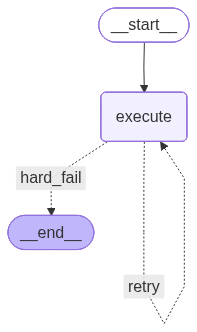

In [5]:
from IPython.display import display, Image

# ==========================================
# Render and display the physical topology of the Package-Skill (Sub-graph)
# ==========================================
print("👇 Internal topology of the Package-Skill (Sub-graph) (Notice the retry loop):")
try:
    display(Image(research_package.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Failed to render sub-graph, please ensure normal network connection (drawing depends on external Mermaid API): {e}")

# ==========================================
# (Optional) Render and display the physical topology of the Main Flow
# ==========================================
# Note: This code needs to be placed after main_builder.compile()
# print("\n👇 Workflow topology of the Main Flow (Notice the sub-graph as a whole node):")
# display(Image(app.get_graph().draw_mermaid_png()))

In [6]:
# Test execution
print("================ Starting Agent Execution ================")
inputs = {"task": "2024 Solid-state battery commercialization progress"}

# We use stream to observe the flowing nodes of the main process
for output in app.stream(inputs):
    # stream will print the state update after each node finishes executing
    pass 

print("\n================ Execution Finished ================")

================ Starting Agent Execution ================

[Main Flow] Planner: Starting to plan tasks...

[Main Flow] Delegating to Research Package-Skill for execution...
    [Inside Package] Executing search tool... (Attempt 1)
    [Inside Package] Caught error: API request timeout (Attempt: 1)
    [Inside Package] Triggering internal retry loop...
    [Inside Package] Executing search tool... (Attempt 2)
    [Inside Package] Caught error: API request timeout (Attempt: 2)
    [Inside Package] Triggering internal retry loop...
    [Inside Package] Executing search tool... (Attempt 3)

[Main Flow] Writer: Data received, starting to write the final report...
-> Final data content: Core research data for [2024 Solid-state battery commercialization progress]: The commercialization of solid-state batteries is expected to boom in 2027.

================ Execution Finished ================


##  Discussion: Limitations & Future Directions

This implementation serves as a **proof-of-concept (PoC)** for the Package-Skill pattern. While it successfully demonstrates local error recovery without breaking the main DAG, there are several advanced frontiers to explore:

### 1. From Automated Retries to Human-in-the-Loop (HITL)
In this tutorial, we used a simple counter-based retry. However, in production-grade DeepResearch Agents, some failures require human judgment (e.g., "The search returned conflicting data; which path should I follow?"). 
* **Next Step:** Integrating LangGraph's `interrupt` and `checkpointer` within the Sub-graph to pause execution for human feedback, ensuring the main DAG remains "suspended" rather than "failed."
* **Additional Idea:** To increase DAG connectivity and executability, we can try to have the Planner designate the HITL node as a convergence point (mandatory passage) for all critical paths when making the plan.

### 2. Multi-Agent Supervision (The Jury System)
Instead of a simple try/except block, the "Validation" node in the Package-Skill could be another LLM agent acting as a **Reviewer**. This would create a "Generator-Discriminator" loop within the package to ensure high-quality data output before returning to the main Planner.

### 3. Dynamic DAG Re-programming
The ultimate goal of a "Creative Agent" is not just to follow a static DAG, but to **re-program its own remaining path** based on the results of a Package-Skill. If a package returns a "Hard Fail," the Planner should be triggered to generate a completely new DAG topology.

---

**Note to Maintainers & Contributors:**
I believe that moving from "Flat DAGs" to "Hierarchical State Machines (Package-Skills)" is the key to building resilient Agents. I am eager to hear your thoughts on how to further standardize this "Packaging" logic within the LangGraph ecosystem!Furthermore, maybe my ideas sound too naive and ridiculous , but I still hope to receive some suggestions.🤗